In [ ]:
import scanpy as sc
import tangram as tg
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ----------------------------
# 1. 加载单细胞和空间数据
# ----------------------------
print("Loading data...")
adata_sc=sc.read('data/adata_sc_MB.h5ad')
adata_st = sc.read('data/adata_ST_MB.h5ad')
sc_label=pd.read_csv('data/sc_label_louvine_MB.txt',sep='\t',header=0,index_col=0)

Loading data...


In [ ]:
adata_sc.obs['cell_type'] = sc_label['cell_type'].astype(str).astype('category')
df_ct=adata_sc.obs

In [ ]:
common_cells = adata_sc.obs_names.intersection(df_ct.index)
print(f"Found {len(common_cells)} / {adata_sc.n_obs} cells with labels.")
if len(common_cells) == 0:
    raise ValueError("No overlapping cell barcodes between scRNA-seq and label file!")

adata_sc = adata_sc[common_cells, :]
adata_sc.obs["cell_type"] = df_ct.loc[common_cells, "cell_type"].values

print("Cell types present:", adata_sc.obs["cell_type"].unique())
print("Finding marker genes...")
sc.tl.rank_genes_groups(adata_sc, groupby='cell_type', use_raw=False)
markers_df = pd.DataFrame(adata_sc.uns["rank_genes_groups"]["names"]).iloc[:100, :]
markers = list(np.unique(markers_df.melt().value.values))
print(f"Selected {len(markers)} unique marker genes.")

print("Preprocessing adatas...")
tg.pp_adatas(adata_sc, adata_st, genes=markers)


print("Running Tangram mapping...")
ad_map = tg.map_cells_to_space(
    adata_sc,
    adata_st,
    mode="cells",
    density_prior='rna_count_based',
    num_epochs=500,
    device='cpu'  


print("Projecting cell type annotations...")
tg.project_cell_annotations(ad_map, adata_st, annotation="cell_type")


print("Plotting spatial cell type prediction...")


-
print("Saving results...")


print("✅ Done!")

Found 11629 / 11629 cells with labels.
Cell types present: ['0', '4', '20', '10', '7', ..., '17', '23', '25', '21', '24']
Length: 26
Categories (26, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
Finding marker genes...
Selected 2037 unique marker genes.
Preprocessing adatas...


INFO:root:2025 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:15834 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.


Running Tangram mapping...


INFO:root:Begin training with 2025 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.472, KL reg: 0.105
Score: 0.680, KL reg: 0.001
Score: 0.691, KL reg: 0.000
Score: 0.693, KL reg: 0.000
Score: 0.694, KL reg: 0.000


INFO:root:Saving results..


Projecting cell type annotations...


INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


Plotting spatial cell type prediction...
Saving results...
✅ Done!


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


cell_types = ad_map.obs['cell_type'].values.reshape(-1, 1)


encoder = OneHotEncoder(sparse_output=False, categories='auto')
onehot = encoder.fit_transform(cell_types)   



In [14]:
sum_per_type = onehot.T @ ad_map.X

In [15]:
sum_per_type.shape

(26, 2695)

In [ ]:
import numpy as np
from scipy.spatial import KDTree
import pandas as pd
label_simulate=pd.read_csv('results/label_simulate.txt',sep='\t',header=0,index_col=0)
change_loc=pd.read_csv('results/ST_location_simulate.txt',sep='\t',header=0,index_col=0)
df_st=sum_per_type.T

In [17]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def compute_avg_neighbor_distance(loc, X, n_neighbors=10):
    """
    Compute for each spot the average distance (Euclidean) in cell-type proportion
    between the spot and its n_neighbors nearest neighbors in space.

    Parameters:
    loc : np.ndarray, shape (N, 2)
        Spatial coordinates of spots.
    X : np.ndarray, shape (N, D)
        Cell-type proportion matrix for each spot (D cell types).
    n_neighbors : int, default 10
        Number of nearest neighbors to consider.

    Returns:
    avg_distances : np.ndarray, shape (N,)
        Average distance for each spot.
    """
    N = loc.shape[0]
    # Find nearest neighbors (excluding self)
    nn = NearestNeighbors(n_neighbors=n_neighbors+1, metric='euclidean')
    nn.fit(loc)
    distances, indices = nn.kneighbors(loc)  # indices shape (N, n_neighbors+1), first is self

    # Exclude self (first column)
    neighbor_indices = indices[:, 1:]  # (N, n_neighbors)
    # neighbor_distances = distances[:, 1:]  # not needed

    avg_distances = np.zeros(N)
    for i in range(N):
        neighbors_X = X[neighbor_indices[i]]  # shape (n_neighbors, D)
        # Compute Euclidean distance between X[i] and each neighbor row
        diff = X[i] - neighbors_X  # broadcasting
        dists = np.linalg.norm(diff, axis=1)  # (n_neighbors,)
        avg_distances[i] = np.mean(dists)
    return avg_distances

In [21]:
loc=change_loc.values
X=df_st
avg_prop = compute_avg_neighbor_distance(loc, X, n_neighbors=10)

AUROC (ROC 曲线下面积): 0.6670
AUPR  (PR 曲线下面积): 0.1096


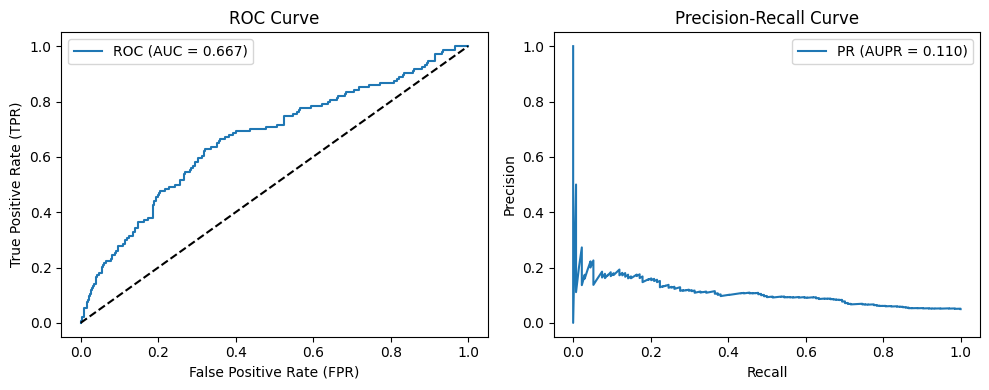

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


scores =  avg_prop
labels = label_simulate['Abberant'].values    # 真实标签（0/1）

fpr, tpr, thresholds_roc = roc_curve(labels, scores)
auroc = auc(fpr, tpr)


precision, recall, thresholds_pr = precision_recall_curve(labels, scores)

aupr = average_precision_score(labels, scores)

print(f"AUROC (ROC 曲线下面积): {auroc:.4f}")
print(f"AUPR  (PR 曲线下面积): {aupr:.4f}")

plt.figure(figsize=(10, 4))

# ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC (AUC = {auroc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()

# PR
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'PR (AUPR = {aupr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()




In [23]:
import pandas as pd
df_roc = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'threshold': thresholds_roc})
df_roc.to_csv('metrics/Tangram_ROC.txt', sep='\t', index=False)

precision_adj = precision[:-1]
recall_adj = recall[:-1]
df_pr = pd.DataFrame({'precision': precision_adj, 'recall': recall_adj, 'threshold': thresholds_pr})
df_pr.to_csv('metrics/Tangram_PR.txt', sep='\t', index=False)